<a href="https://colab.research.google.com/github/artadchy/Study-Material-/blob/main/Copy_of_Untitled5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/healthcare-dataset-stroke-data.csv")

In [ ]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
df.shape

(5110, 12)

In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


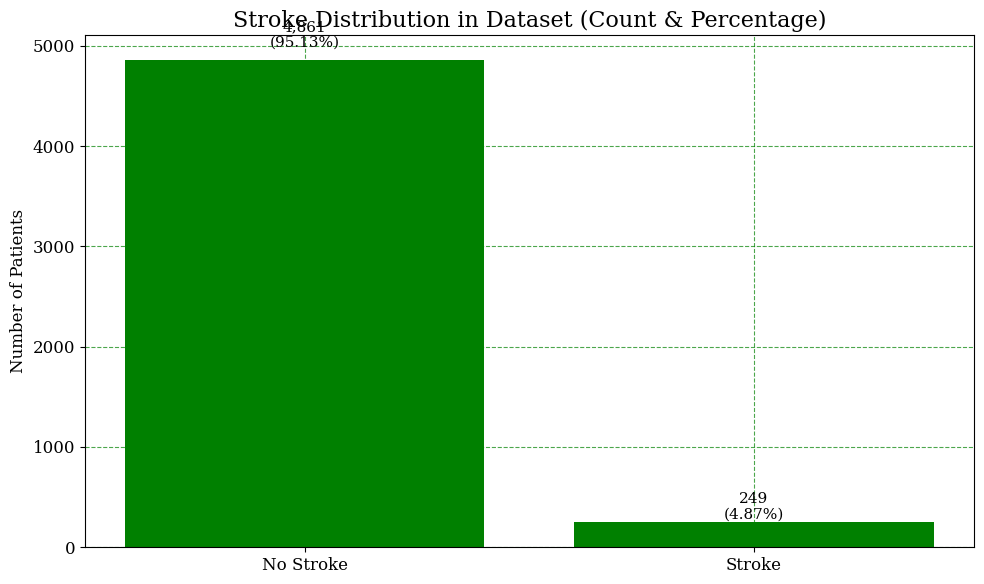

In [ ]:
import matplotlib.pyplot as plt

stroke_counts = df['stroke'].value_counts().sort_index()
stroke_percentages = (stroke_counts / stroke_counts.sum()) * 100


plt.figure(figsize=(10, 6))
bars = plt.bar(
    ['No Stroke', 'Stroke'],
    stroke_counts.values,
    color='green'
)


for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{stroke_counts.values[idx]:,}'
    percent_text = f'({stroke_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02 * height,
        f'{count_text}\n{percent_text}',
        ha='center',
        va='bottom',
        fontsize=11
    )


plt.title('Stroke Distribution in Dataset (Count & Percentage)', fontsize=16)
plt.ylabel('Number of Patients')


plt.grid(axis='both', linestyle='--', alpha=0.7, color='green')

plt.tight_layout()
plt.show()


In [ ]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("Columns with Missing Values:\n", missing_values)

df['bmi'] = df['bmi'].fillna(df['bmi'].median())

print("Missing values after filling:", df.isnull().sum().sum())


Columns with Missing Values:
 bmi    201
dtype: int64
Missing values after filling: 0


In [ ]:
# Print the names of the features (columns)
print(df.columns)

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1️⃣ Replace infinity values with NaN (safety step)
df = df.replace([np.inf, -np.inf], np.nan)

# 2️⃣ Handle missing values (ONLY BMI has missing values)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# 3️⃣ Define columns explicitly (BEST PRACTICE)

# Numerical columns to SCALE
num_cols = ['age', 'avg_glucose_level', 'bmi']

# Binary columns (DO NOT scale)
binary_cols = ['hypertension', 'heart_disease']

# Categorical columns to ENCODE
cat_cols = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

# Target and ID (leave untouched)
target_col = 'stroke'
id_col = 'id'

# 4️⃣ Scale numerical features
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# 5️⃣ Encode categorical features
encoder = LabelEncoder()
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

# 6️⃣ Final check
print("Any missing values left?", df.isnull().sum().sum())

df.head()


Any missing values left? 0


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,1.051434,0,1,1,2,1,2.706375,1.005086,1,1
1,51676,0,0.786070,0,0,1,3,0,2.121559,-0.098981,2,1
2,31112,1,1.626390,0,1,1,2,0,-0.005028,0.472536,2,1
3,60182,0,0.255342,0,0,1,2,1,1.437358,0.719327,3,1
4,1665,0,1.582163,1,0,1,3,0,1.501184,-0.631531,2,1


In [ ]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,1.051434,0,1,1,2,1,2.706375,1.005086,1,1
1,51676,0,0.786070,0,0,1,3,0,2.121559,-0.098981,2,1
2,31112,1,1.626390,0,1,1,2,0,-0.005028,0.472536,2,1
3,60182,0,0.255342,0,0,1,2,1,1.437358,0.719327,3,1
4,1665,0,1.582163,1,0,1,3,0,1.501184,-0.631531,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0,1.626390,1,0,1,2,1,-0.494658,-0.098981,2,0
5106,44873,0,1.670617,0,0,1,3,1,0.420775,1.446713,2,0
5107,19723,0,-0.363842,0,0,1,3,0,-0.511443,0.225745,2,0
5108,37544,1,0.343796,0,0,1,2,0,1.328257,-0.423706,1,0


In [ ]:
df.drop(columns=['id'], inplace=True)


In [ ]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,1.051434,0,1,1,2,1,2.706375,1.005086,1,1
1,0,0.786070,0,0,1,3,0,2.121559,-0.098981,2,1
2,1,1.626390,0,1,1,2,0,-0.005028,0.472536,2,1
3,0,0.255342,0,0,1,2,1,1.437358,0.719327,3,1
4,0,1.582163,1,0,1,3,0,1.501184,-0.631531,2,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,0,1.626390,1,0,1,2,1,-0.494658,-0.098981,2,0
5106,0,1.670617,0,0,1,3,1,0.420775,1.446713,2,0
5107,0,-0.363842,0,0,1,3,0,-0.511443,0.225745,2,0
5108,1,0.343796,0,0,1,2,0,1.328257,-0.423706,1,0


In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
df1 = df.copy()
df2 = df.copy()
df3 = df.copy()

In [ ]:
df1['stroke_label'] = df1['stroke'].apply(lambda x: 'No Stroke' if x == 0 else 'Stroke')


In [ ]:
print(df1['stroke'].value_counts())

stroke
0    4861
1     249
Name: count, dtype: int64


In [ ]:
X = df1.drop(columns=['stroke', 'stroke_label'], errors='ignore')  # keep numeric features only

y = df1['stroke']  # binary 0/1 target


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.3,          # 30% for testing
    stratify=y,             # Keep stroke class balance in train/test
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (3577, 10)
X_test shape:  (1533, 10)
y_train shape: (3577,)
y_test shape:  (1533,)


Accuracy:  0.9035
Precision: 0.9192
Recall:    0.9035
F1 Score:  0.9110
ROC-AUC:   0.5761


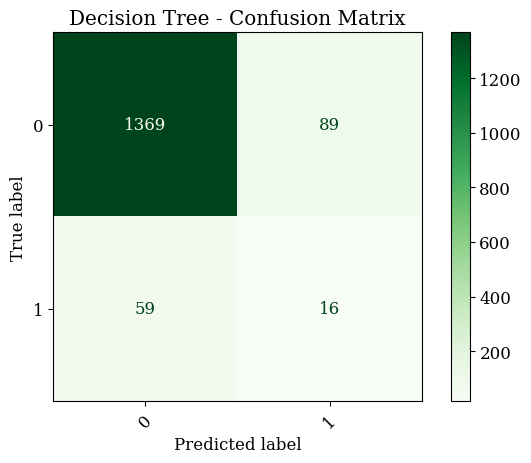

Classification Report:
              precision    recall  f1-score   support

           0    0.95868   0.93896   0.94872      1458
           1    0.15238   0.21333   0.17778        75

    accuracy                        0.90346      1533
   macro avg    0.55553   0.57615   0.56325      1533
weighted avg    0.91924   0.90346   0.91100      1533



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict on Test Set
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:,1]  # probability for ROC-AUC

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

# Print Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

#  Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))




Accuracy:  0.94586
Precision: 0.90976
Recall:    0.94586
F1 Score:  0.92575


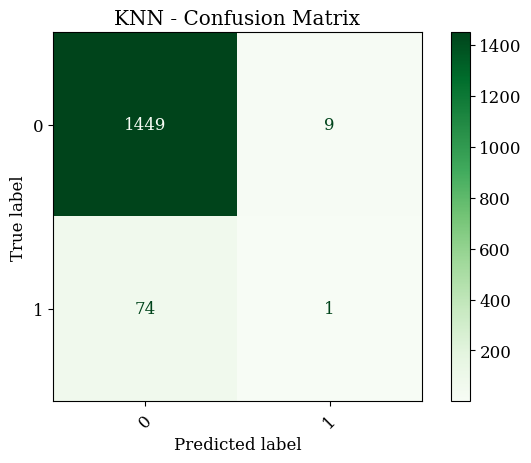

Classification Report:
              precision    recall  f1-score   support

           0    0.95141   0.99383   0.97216      1458
           1    0.10000   0.01333   0.02353        75

    accuracy                        0.94586      1533
   macro avg    0.52571   0.50358   0.49784      1533
weighted avg    0.90976   0.94586   0.92575      1533



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))


Accuracy:  0.9511
Precision: 0.9045
Recall:    0.9511
F1 Score:  0.9272


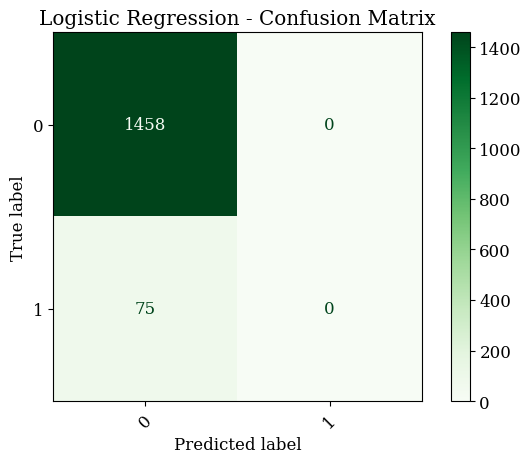

Classification Report:
              precision    recall  f1-score   support

           0    0.95108   1.00000   0.97492      1458
           1    0.00000   0.00000   0.00000        75

    accuracy                        0.95108      1533
   macro avg    0.47554   0.50000   0.48746      1533
weighted avg    0.90455   0.95108   0.92723      1533



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

lr_model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=lr_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))


In [ ]:
X = df2.drop(columns=['stroke', 'stroke_label'], errors='ignore')
y = df2['stroke']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (4088, 10)
X_test shape:  (1022, 10)
y_train shape: (4088,)
y_test shape:  (1022,)


Accuracy:  0.9159
Precision: 0.9189
Recall:    0.9159
F1 Score:  0.9174


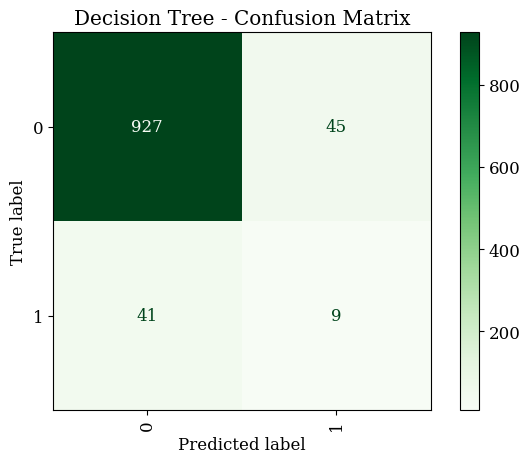

Classification Report:
              precision    recall  f1-score   support

           0    0.95764   0.95370   0.95567       972
           1    0.16667   0.18000   0.17308        50

    accuracy                        0.91585      1022
   macro avg    0.56216   0.56685   0.56437      1022
weighted avg    0.91895   0.91585   0.91738      1022



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))


Accuracy:  0.94423
Precision: 0.90423
Recall:    0.94423
F1 Score:  0.92379


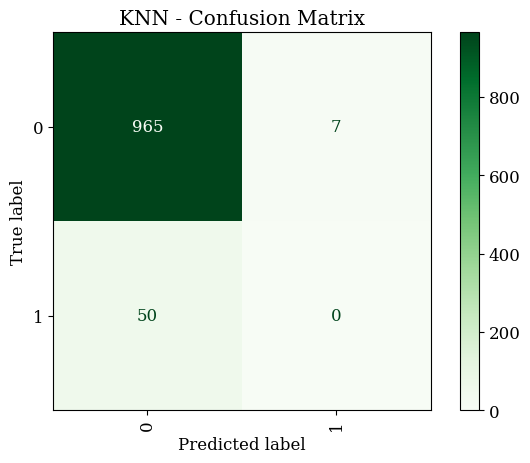

Classification Report:
              precision    recall  f1-score   support

           0    0.95074   0.99280   0.97131       972
           1    0.00000   0.00000   0.00000        50

    accuracy                        0.94423      1022
   macro avg    0.47537   0.49640   0.48566      1022
weighted avg    0.90423   0.94423   0.92379      1022



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))


Accuracy:  0.9501
Precision: 0.9045
Recall:    0.9501
F1 Score:  0.9267


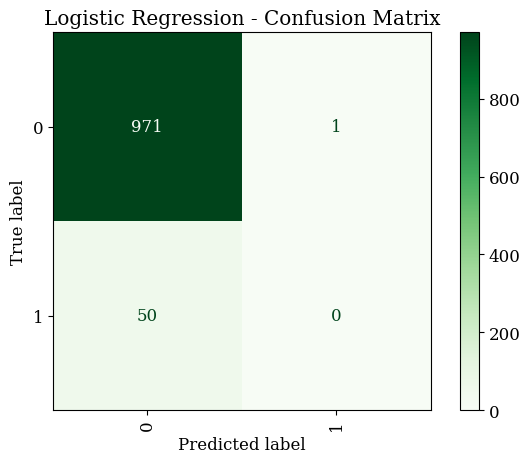

Classification Report:
              precision    recall  f1-score   support

           0    0.95103   0.99897   0.97441       972
           1    0.00000   0.00000   0.00000        50

    accuracy                        0.95010      1022
   macro avg    0.47551   0.49949   0.48721      1022
weighted avg    0.90450   0.95010   0.92674      1022



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
lr_model = LogisticRegression(random_state=42, max_iter=2000, solver="liblinear")
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=lr_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))


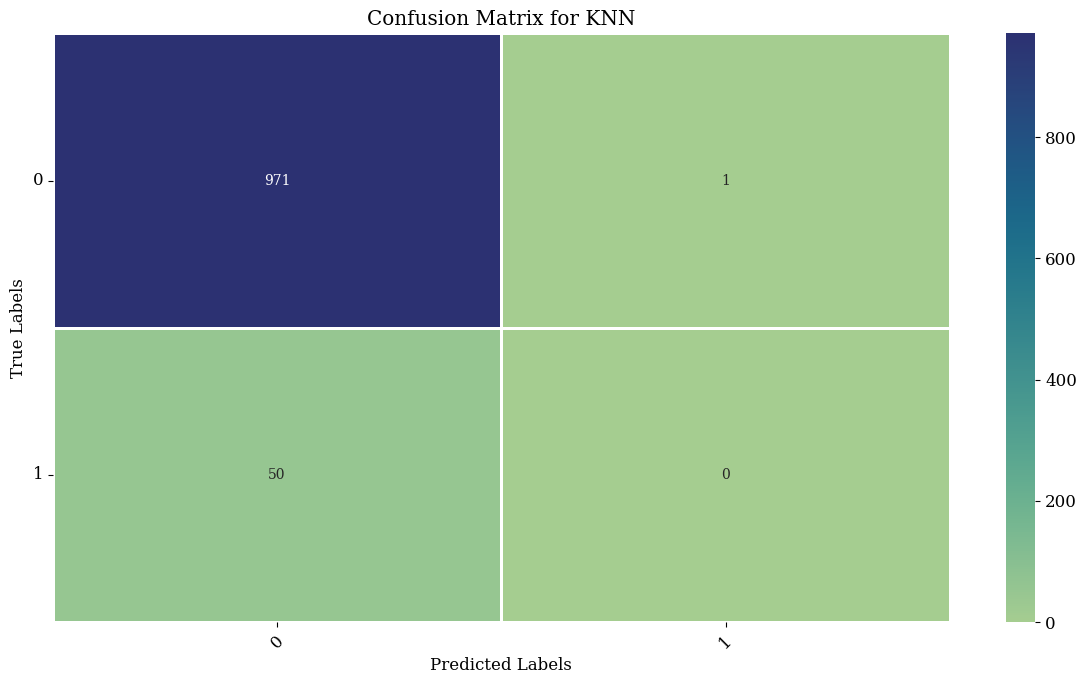

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)
cmap = sns.color_palette("crest", as_cmap=True)
class_labels = knn_model.classes_
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')
ax.set_title("Confusion Matrix for KNN")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)
plt.tight_layout()
plt.show()
